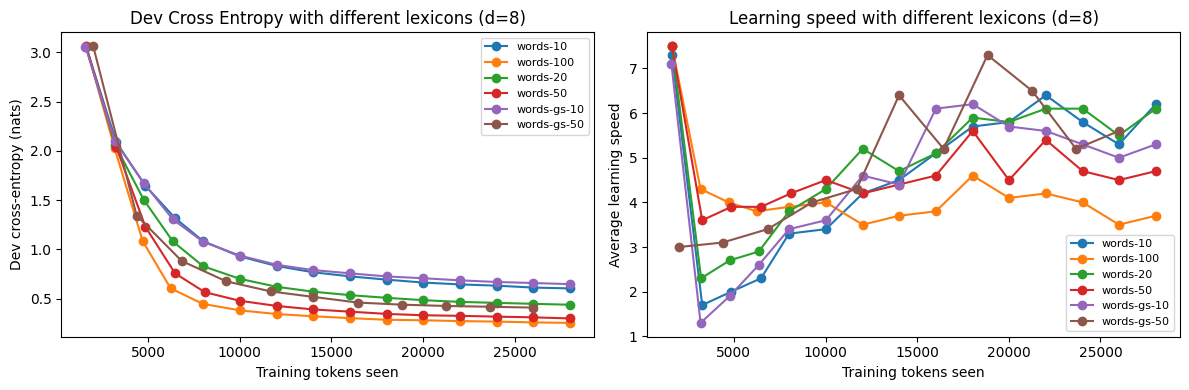

In [13]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- 配置：不同 lexicon 的 log 路径 ----------
lexicon_paths = {
    "words-10":  "logs/q2_en_birnn_d8_w10.log",
    "words-20":  "logs/q2_en_birnn_d8_w20.log",
    "words-50":  "logs/q2_en_birnn_d8_w50.log",
    "words-100": "logs/q2_en_birnn_d8_w100.log",
    "words-gs-10": "logs/q2_en_birnn_d8_wgs10.log",
    "words-gs-50": "logs/q2_en_birnn_d8_wgs50.log",
}

def parse_logs_for_curves(paths_dict, save_pattern_prefix):
    """
    paths_dict: dict name -> log_path
    save_pattern_prefix: 模型文件名前缀, 比如 'en-birnn-d8-'。

    返回一个 DataFrame，列包括:
      - setting           (哪个 lexicon)
      - tokens_seen       (训练过多少 token，对应 ckpt 后缀)
      - dev_cross_entropy (dev CE)
      - avg_learning_speed(平均 learning speed)
    """
    records = []

    ce_re   = re.compile(r"INFO:eval:Cross-entropy:\s+([0-9.]+)\s+nats")
    save_re = re.compile(
        rf"Saved model to model/{re.escape(save_pattern_prefix)}.*-(\d+)\.pkl"
    )
    ls_re   = re.compile(r"Average learning speed:\s+([0-9.]+)")

    for name, path in paths_dict.items():
        text = Path(path).read_text()
        lines = text.splitlines()
        i = 0
        while i < len(lines):
            line = lines[i]
            m_ce = ce_re.search(line)
            if m_ce:
                ce = float(m_ce.group(1))
                # 向后几行找对应的 “Saved model” 行
                j = i + 1
                step = None
                while j < len(lines) and j <= i + 6:
                    m_save = save_re.search(lines[j])
                    if m_save:
                        step = int(m_save.group(1))
                        break
                    j += 1

                # 再向后找 “Average learning speed”
                ls = None
                if step is not None:
                    k = j + 1
                    while k < len(lines) and k <= j + 6:
                        m_ls = ls_re.search(lines[k])
                        if m_ls:
                            ls = float(m_ls.group(1))
                            break
                        k += 1

                    records.append({
                        "setting":            name,
                        "tokens_seen":        step,
                        "dev_cross_entropy":  ce,
                        "avg_learning_speed": ls,
                    })
                    i = k
                else:
                    i += 1
            else:
                i += 1

    df = (pd.DataFrame(records)
          .sort_values(["setting", "tokens_seen"])
          .reset_index(drop=True))
    return df


if __name__ == "__main__":
    # 解析 log
    df_lex = parse_logs_for_curves(lexicon_paths, save_pattern_prefix="en-birnn-d8-")

    # 存成 CSV，方便你在别的地方画图 / 做表
    df_lex.to_csv("q2_word_embedding_training_curves.csv", index=False)

    # 一张图里放左右两个子图
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 行 2 列

    # 左图: Dev cross-entropy vs training tokens
    ax_ce = axes[0]
    for name in df_lex["setting"].unique():
        sub = df_lex[df_lex["setting"] == name]
        ax_ce.plot(sub["tokens_seen"], sub["dev_cross_entropy"],
                   marker="o", label=name)
    ax_ce.set_xlabel("Training tokens seen")
    ax_ce.set_ylabel("Dev cross-entropy (nats)")
    ax_ce.set_title("Dev Cross Entropy with different lexicons (d=8)")
    ax_ce.legend(fontsize=8)

    # 右图: Learning speed vs training tokens
    ax_ls = axes[1]
    for name in df_lex["setting"].unique():
        sub = df_lex[df_lex["setting"] == name]
        ax_ls.plot(sub["tokens_seen"], sub["avg_learning_speed"],
                   marker="o", label=name)
    ax_ls.set_xlabel("Training tokens seen")
    ax_ls.set_ylabel("Average learning speed")
    ax_ls.set_title("Learning speed with different lexicons (d=8)")
    ax_ls.legend(fontsize=8)

    plt.tight_layout()

    # 如果想保存成 pdf：
    plt.savefig("q2_lexicon_training_curves.pdf", bbox_inches="tight")

    plt.show()


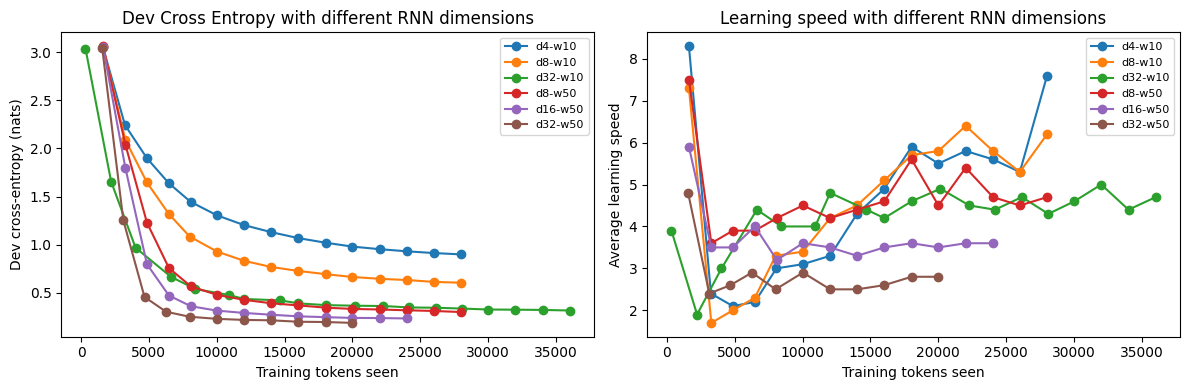

In [18]:
# 3. 一张图里放左右两个子图：左边 CE，右边 learning speed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 想要的顺序（按 RNN dim 和 lexicon）
order = ["d4-w10", "d8-w10","d32-w10", "d8-w50", "d16-w50", "d32-w50"]

# 左图：Dev CE vs tokens
ax_ce = axes[0]
for setting in order:
    if setting not in df_rnn["setting"].unique():
        continue  # 防止某个 log 缺失时报错
    sub = df_rnn[df_rnn["setting"] == setting]
    ax_ce.plot(
        sub["tokens_seen"],
        sub["dev_cross_entropy"],
        marker="o",
        label=setting,
    )
ax_ce.set_xlabel("Training tokens seen")
ax_ce.set_ylabel("Dev cross-entropy (nats)")
ax_ce.set_title("Dev Cross Entropy with different RNN dimensions")
ax_ce.legend(fontsize=8)

# 右图：learning speed vs tokens
ax_ls = axes[1]
for setting in order:
    if setting not in df_rnn["setting"].unique():
        continue
    sub = df_rnn[df_rnn["setting"] == setting]
    ax_ls.plot(
        sub["tokens_seen"],
        sub["avg_learning_speed"],
        marker="o",
        label=setting,
    )
ax_ls.set_xlabel("Training tokens seen")
ax_ls.set_ylabel("Average learning speed")
ax_ls.set_title("Learning speed with different RNN dimensions")
ax_ls.legend(fontsize=8)

plt.tight_layout()
plt.savefig("q2_rnn_dim_training_curves.pdf", bbox_inches="tight")
plt.show()


setting
b10        12
b30        15
b60        15
lr0.01     15
lr0.05      7
lr0.1       8
reg0       15
reg0.01    15
reg0.1     15
dtype: int64


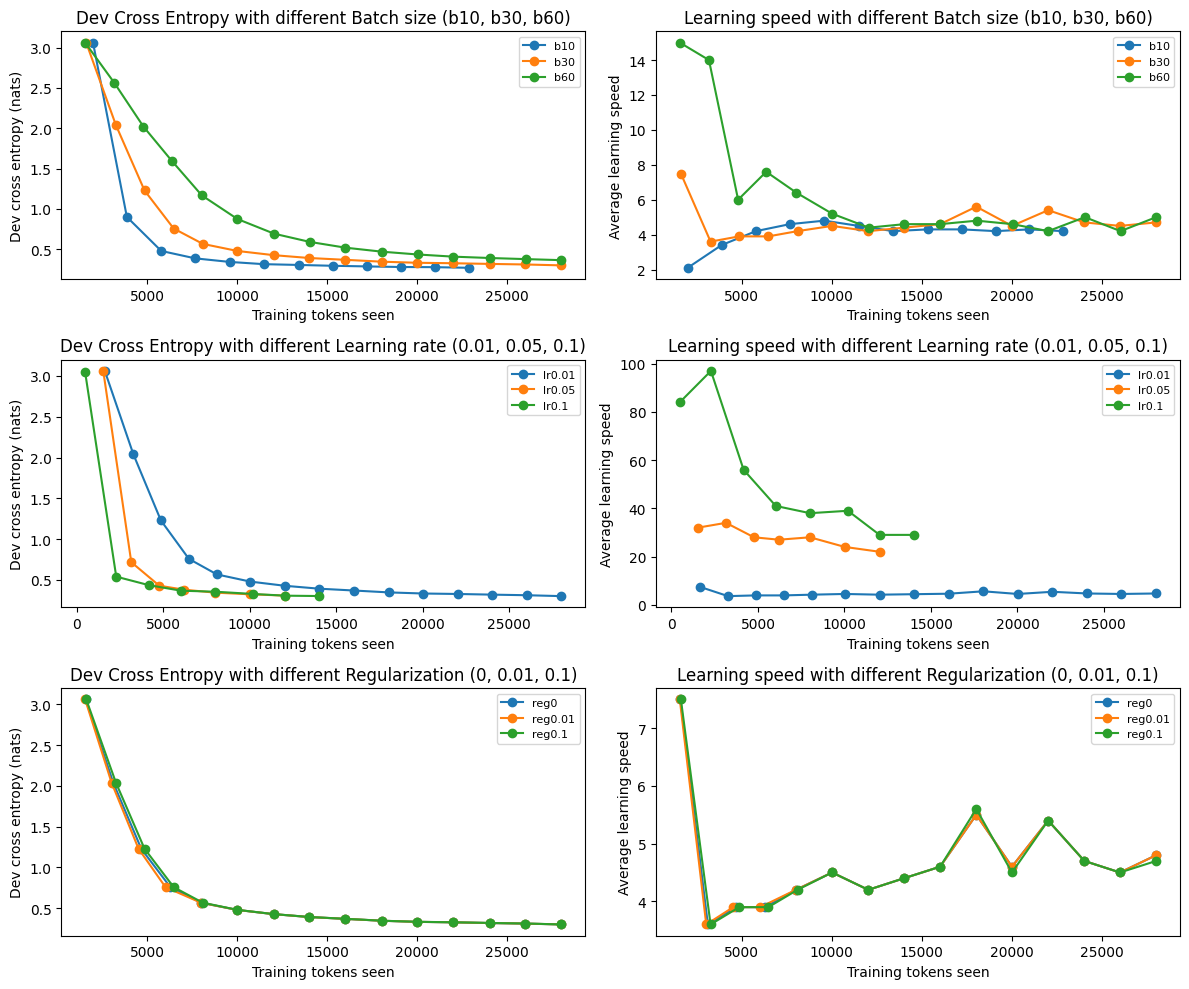

In [20]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# 1. 配置 log 文件路径
paths_hp = {
    "b10":      "logs/q2_en_birnn_d8_w50_b10.log",      # batch size 10
    "b60":      "logs/q2_en_birnn_d8_w50_b60.log",      # batch size 60
    "lr0.05":   "logs/q2_en_birnn_d8_w50_lr0.05.log",   # learning rate 0.05
    "lr0.1":     "logs/q2_en_birnn_d8_w50_lr0.1.log",     # reg = 0
    "reg0.01":  "logs/q2_en_birnn_d8_w50_reg0.01.log",  # reg = 0.01
    "reg0":     "logs/q2_en_birnn_d8_w50_reg0.log",     # reg = 0
    # baseline: batch = 30, lr = 0.01, reg = 0.1
    "reg0.1": "logs/q2_en_birnn_d8_w50.log",
    "b30": "logs/q2_en_birnn_d8_w50.log",
    "lr0.01": "logs/q2_en_birnn_d8_w50.log",
}

records = []

for setting, path in paths_hp.items():
    text = Path(path).read_text()
    lines = text.splitlines()
    i = 0
    while i < len(lines):
        line = lines[i]

        # 找 dev cross-entropy
        m_ce = re.search(r"INFO:eval:Cross-entropy:\s+([0-9.]+)\s+nats", line)
        if not m_ce:
            i += 1
            continue
        ce = float(m_ce.group(1))

        step = None
        j = i + 1
        while j < len(lines) and j <= i + 6:
            m_save = re.search(r"Saved model to .*-(\d+)\.pkl", lines[j])
            if m_save:
                step = int(m_save.group(1))
                break
            j += 1

        # 再往后找 Average learning speed
        ls = None
        if step is not None:
            k = j + 1
            while k < len(lines) and k <= j + 6:
                m_ls = re.search(
                    r"Average learning speed:\s+([0-9.]+)",
                    lines[k],
                )
                if m_ls:
                    ls = float(m_ls.group(1))
                    break
                k += 1

            records.append(
                {
                    "setting": setting,
                    "tokens_seen": step,
                    "dev_cross_entropy": ce,
                    "avg_learning_speed": ls,
                }
            )
            i = k if ls is not None else j + 1
        else:
            i += 1

df_hp = pd.DataFrame(records).sort_values(
    ["setting", "tokens_seen"]
).reset_index(drop=True)

print(df_hp.groupby("setting").size())
df_hp.to_csv("q2_hyperparam_training_curves.csv", index=False)
# 小工具：3x2 子图，一次性画所有超参数对比
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# 定义三个 group：batch / lr / reg
groups = [
    {
        "filter": lambda df: df["setting"].isin(["b10", "b30", "b60"]),
        "title": "Batch size (b10, b30, b60)",
    },
    {
        "filter": lambda df: df["setting"].isin(["lr0.01", "lr0.05", "lr0.1"]),
        "title": "Learning rate (0.01, 0.05, 0.1)",
    },
    {
        "filter": lambda df: df["setting"].isin(["reg0", "reg0.01", "reg0.1"]),
        "title": "Regularization (0, 0.01, 0.1)",
    },
]

for row, g in enumerate(groups):
    sub = df_hp[g["filter"](df_hp)].copy()
    if sub.empty:
        continue

    # 左列：Dev CE vs tokens
    ax_ce = axes[row, 0]
    for setting in sub["setting"].unique():
        ssub = sub[sub["setting"] == setting]
        ax_ce.plot(
            ssub["tokens_seen"],
            ssub["dev_cross_entropy"],
            marker="o",
            label=setting,
        )
    ax_ce.set_xlabel("Training tokens seen")
    ax_ce.set_ylabel("Dev cross entropy (nats)")
    ax_ce.set_title(f"Dev Cross Entropy with different {g['title']}")
    ax_ce.legend(fontsize=8)

    # 右列：learning speed vs tokens
    ax_ls = axes[row, 1]
    for setting in sub["setting"].unique():
        ssub = sub[sub["setting"] == setting]
        ax_ls.plot(
            ssub["tokens_seen"],
            ssub["avg_learning_speed"],
            marker="o",
            label=setting,
        )
    ax_ls.set_xlabel("Training tokens seen")
    ax_ls.set_ylabel("Average learning speed")
    ax_ls.set_title(f"Learning speed with different {g['title']}")
    ax_ls.legend(fontsize=8)

plt.tight_layout()

# 如果想存成一个 pdf：
plt.savefig("q2_other_training_curves.pdf", bbox_inches="tight")

plt.show()
